#  Housing Price Analysis — Mini Project
**Student:** Huzaifa Toufeeq  
**Company:** DEVSIL (SMC-PRIVATE) LIMITED  
**Date:** January 26, 2025  

---

##  Project Overview

This notebook presents a structured end-to-end analysis of the **Ames Housing Dataset** — a well-known real-estate dataset commonly used in data science competitions (available on Kaggle). The goal is to:

- Clean and preprocess the dataset
- Perform exploratory data analysis (EDA)
- Visualize relationships between features and house prices
- Apply statistical tests to validate observed patterns
- Draw actionable conclusions

**Techniques Used:** `Pandas`, `NumPy`, `Matplotlib`, `Seaborn`, `SciPy (t-test)`

---

##  Step 1 — Import Libraries

We start by importing all the libraries we will need throughout this analysis.

In [1]:
# Core libraries
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

# Statistical testing
from scipy import stats

# Display settings
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.2f}'.format)

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'

print(" All libraries imported successfully.")

 All libraries imported successfully.


---

##  Step 2 — Load the Dataset

We load the housing CSV dataset and take an initial look at its structure.

In [2]:
# Load dataset
df = pd.read_csv('housing_dataset.csv')

print(f" Dataset Shape: {df.shape[0]} rows × {df.shape[1]} columns")
print("\n First 5 rows:")
df.head()

 Dataset Shape: 40 rows × 81 columns

 First 5 rows:


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,...,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.00,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,...,0,NaN,Attchd,2003,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.00,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,...,1,TA,Attchd,1976,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.00,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,...,1,TA,Attchd,2001,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.00,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,...,1,Gd,Detchd,1998,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.00,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,...,1,TA,Attchd,2000,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [3]:
# Column data types
print(" Data Types:\n")
print(df.dtypes.value_counts())
print("\n")
df.info()

 Data Types:

str        42
int64      37
float64     2
Name: count, dtype: int64


<class 'pandas.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             40 non-null     int64  
 1   MSSubClass     40 non-null     int64  
 2   MSZoning       40 non-null     str    
 3   LotFrontage    24 non-null     float64
 4   LotArea        40 non-null     int64  
 5   Street         40 non-null     str    
 6   Alley          1 non-null      str    
 7   LotShape       40 non-null     str    
 8   LandContour    40 non-null     str    
 9   Utilities      40 non-null     str    
 10  LotConfig      40 non-null     str    
 11  LandSlope      40 non-null     str    
 12  Neighborhood   40 non-null     str    
 13  Condition1     40 non-null     str    
 14  Condition2     40 non-null     str    
 15  BldgType       40 non-null     str    
 16  HouseStyle     40 non-null 

---

##  Step 3 — Data Cleaning

### 3.1 Missing Value Analysis

A critical step in any data project is identifying and handling missing data. We compute both the count and percentage of nulls.

In [4]:
# Compute missing values
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing (%)': missing_pct
}).query('`Missing Count` > 0').sort_values('Missing (%)', ascending=False)

print(f"🔎 Columns with missing values: {len(missing_df)}")
print(missing_df)

🔎 Columns with missing values: 7
             Missing Count  Missing (%)
PoolQC                  40       100.00
Alley                   39        97.50
MiscFeature             38        95.00
Fence                   36        90.00
MasVnrType              29        72.50
FireplaceQu             21        52.50
LotFrontage             16        40.00


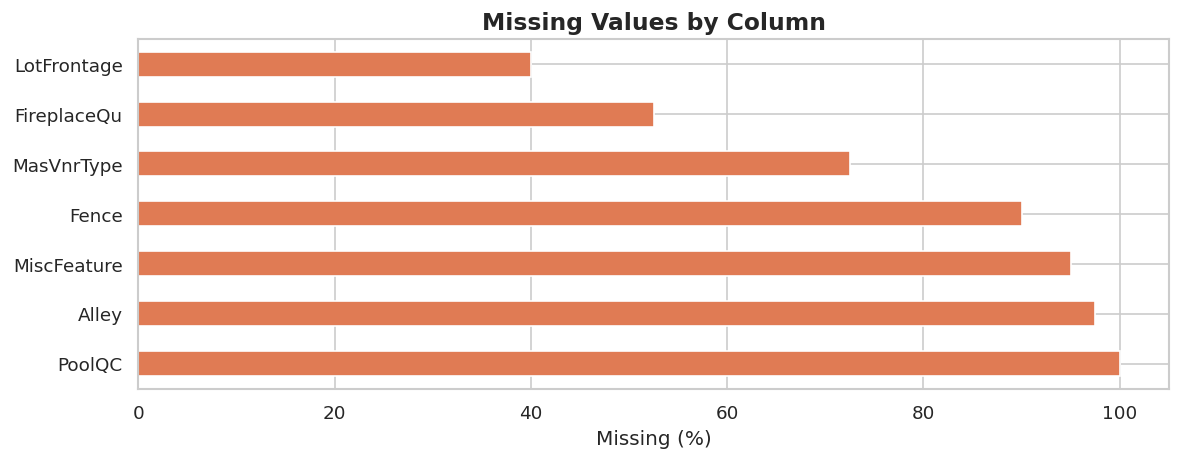

In [12]:
# Visualize missing values
if len(missing_df) > 0:
    fig, ax = plt.subplots(figsize=(10, 4))
    missing_df['Missing (%)'].plot(kind='barh', ax=ax, color='#E07B54', edgecolor='white')
    ax.set_xlabel('Missing (%)', fontsize=12)
    ax.set_title('Missing Values by Column', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('missing_values.png', bbox_inches='tight')
    plt.show()
else:
    print(" No missing values found in the dataset.")
    # saving the png in graphs folder
    plt.savefig('.//graphs/no_missing_values.png', bbox_inches='tight')

    

### 3.2 Handle Missing Values

- **Numeric columns** (e.g., `LotFrontage`) → Fill with **median** (robust to outliers)
- **Categorical columns** → Fill with `'Unknown'` or `'None'` as appropriate

In [13]:
# Separate numeric and categorical columns
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df.select_dtypes(include=['object']).columns.tolist()

print(f" Numeric columns : {len(num_cols)}")
print(f" Categorical columns: {len(cat_cols)}")

# Fill numeric missing values with median
for col in num_cols:
    if df[col].isnull().sum() > 0:
        median_val = df[col].median()
        df[col].fillna(median_val, inplace=True)
        print(f"  → Filled '{col}' with median: {median_val:.1f}")

# Fill categorical missing values
for col in cat_cols:
    if df[col].isnull().sum() > 0:
        df[col].fillna('Unknown', inplace=True)
        print(f"  → Filled '{col}' with 'Unknown'")

print(f"\n Missing values after cleaning: {df.isnull().sum().sum()}")

 Numeric columns : 39
 Categorical columns: 42
  → Filled 'LotFrontage' with median: 69.0
  → Filled 'PoolQC' with median: nan
  → Filled 'Alley' with 'Unknown'
  → Filled 'MasVnrType' with 'Unknown'
  → Filled 'FireplaceQu' with 'Unknown'
  → Filled 'Fence' with 'Unknown'
  → Filled 'MiscFeature' with 'Unknown'

 Missing values after cleaning: 219


### 3.3 Duplicate Check

In [14]:
duplicates = df.duplicated().sum()
print(f" Duplicate rows: {duplicates}")

if duplicates > 0:
    df.drop_duplicates(inplace=True)
    print(f" Duplicates removed. New shape: {df.shape}")
else:
    print(" No duplicates found.")

 Duplicate rows: 0
 No duplicates found.


---

##  Step 4 — Descriptive Statistics

Before diving into visualizations, we examine the key numerical features statistically.

In [15]:
# Key columns for analysis
key_cols = ['GrLivArea', 'TotalBsmtSF', 'GarageArea', 'LotArea',
            'OverallQual', 'YearBuilt', 'BedroomAbvGr', 'SalePrice']

key_cols = [c for c in key_cols if c in df.columns]
df[key_cols].describe().T.rename(columns={'50%': 'median'})

,count,mean,std,min,25%,median,75%,max
GrLivArea,40.00,1308.50,456.87,694.00,1003.00,1128.50,1698.00,2324.00
TotalBsmtSF,40.00,1003.77,218.99,519.00,859.00,995.50,1146.50,1686.00
GarageArea,40.00,458.52,150.01,205.00,330.00,472.00,528.00,840.00
LotArea,40.00,9396.45,2214.08,5858.00,7485.50,9525.00,10662.00,14260.00
OverallQual,40.00,6.15,1.21,5.00,5.00,6.00,7.00,9.00
YearBuilt,40.00,1967.58,25.54,1915.00,1956.50,1966.00,1980.25,2007.00
BedroomAbvGr,40.00,2.85,0.62,1.00,3.00,3.00,3.00,4.00
SalePrice,40.00,182440.00,67816.94,90000.00,137250.00,158000.00,230000.00,345000.00


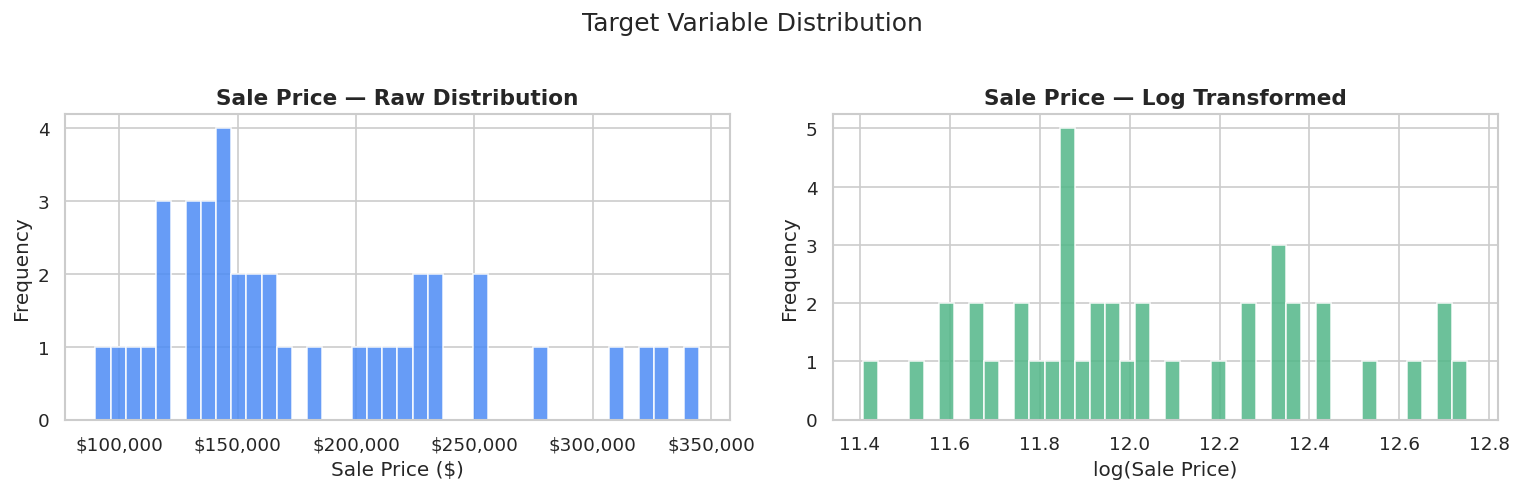


 Sale Price Statistics:
   Mean  : $182,440
   Median: $158,000
   Std   : $67,817
   Min   : $90,000
   Max   : $345,000


In [16]:
# Distribution of the target variable
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Raw distribution
axes[0].hist(df['SalePrice'], bins=40, color='#4C8BF5', edgecolor='white', alpha=0.85)
axes[0].set_title('Sale Price — Raw Distribution', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Sale Price ($)')
axes[0].set_ylabel('Frequency')
axes[0].xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x:,.0f}'))

# Log-transformed
axes[1].hist(np.log1p(df['SalePrice']), bins=40, color='#52B788', edgecolor='white', alpha=0.85)
axes[1].set_title('Sale Price — Log Transformed', fontsize=13, fontweight='bold')
axes[1].set_xlabel('log(Sale Price)')
axes[1].set_ylabel('Frequency')

plt.suptitle('Target Variable Distribution', fontsize=15, y=1.02)
plt.tight_layout()
plt.savefig('price_distribution.png', bbox_inches='tight')
plt.show()

print(f"\n Sale Price Statistics:")
print(f"   Mean  : ${df['SalePrice'].mean():,.0f}")
print(f"   Median: ${df['SalePrice'].median():,.0f}")
print(f"   Std   : ${df['SalePrice'].std():,.0f}")
print(f"   Min   : ${df['SalePrice'].min():,.0f}")
print(f"   Max   : ${df['SalePrice'].max():,.0f}")

---

##  Step 5 — Exploratory Data Analysis (EDA)

### 5.1 House Size vs. Sale Price

We explore the most intuitive relationship — **above-ground living area** vs **sale price**.

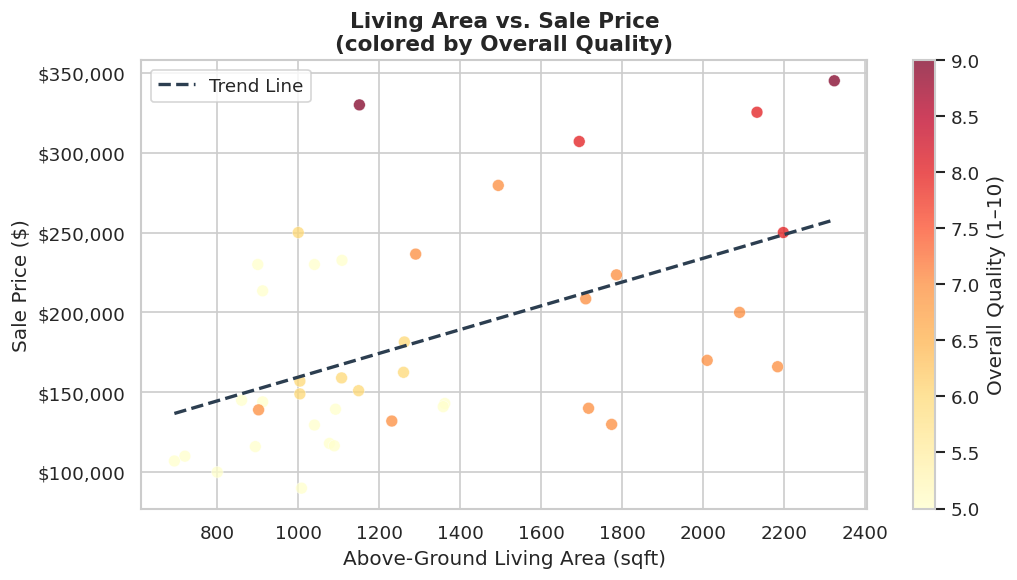


📌 Pearson Correlation (GrLivArea vs SalePrice): r = 0.5011


In [17]:
fig, ax = plt.subplots(figsize=(9, 5))

sc = ax.scatter(
    df['GrLivArea'], df['SalePrice'],
    c=df['OverallQual'], cmap='YlOrRd',
    alpha=0.75, edgecolors='white', linewidths=0.3, s=50
)

# Regression line
m, b = np.polyfit(df['GrLivArea'], df['SalePrice'], 1)
x_line = np.linspace(df['GrLivArea'].min(), df['GrLivArea'].max(), 100)
ax.plot(x_line, m * x_line + b, color='#2C3E50', linewidth=2, linestyle='--', label='Trend Line')

plt.colorbar(sc, ax=ax, label='Overall Quality (1–10)')
ax.set_xlabel('Above-Ground Living Area (sqft)', fontsize=12)
ax.set_ylabel('Sale Price ($)', fontsize=12)
ax.set_title('Living Area vs. Sale Price\n(colored by Overall Quality)', fontsize=13, fontweight='bold')
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.legend()
plt.tight_layout()
plt.savefig('area_vs_price.png', bbox_inches='tight')
plt.show()

# Correlation
corr = df['GrLivArea'].corr(df['SalePrice'])
print(f"\n📌 Pearson Correlation (GrLivArea vs SalePrice): r = {corr:.4f}")

### 5.2 Overall Quality vs. Sale Price

**Overall Quality** is rated 1–10 and typically has a strong association with price.

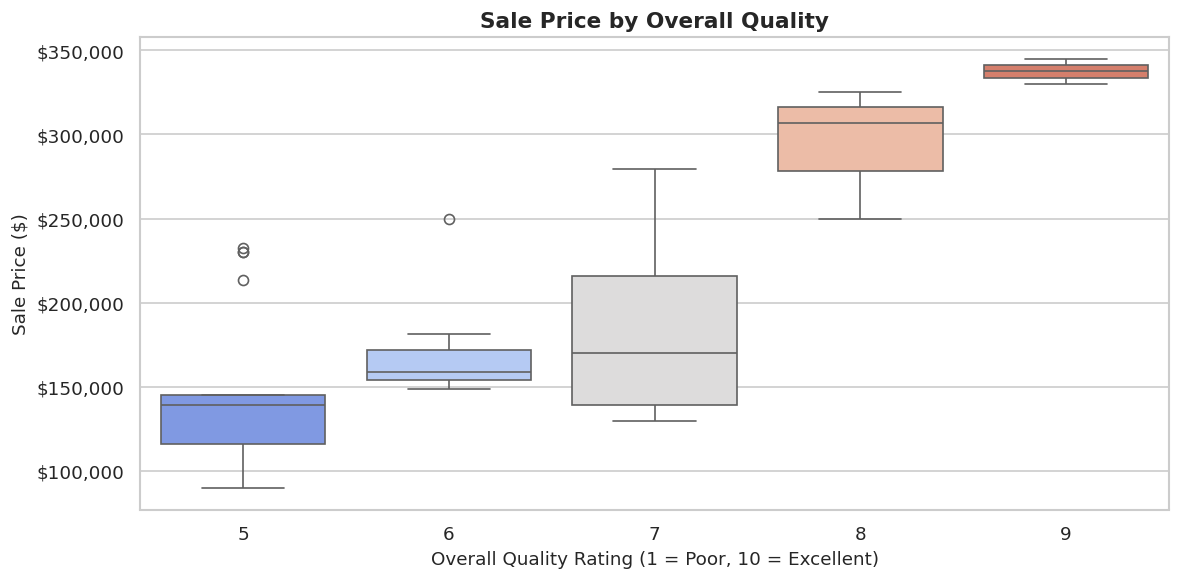

In [18]:
fig, ax = plt.subplots(figsize=(10, 5))

sns.boxplot(
    data=df, x='OverallQual', y='SalePrice',
    palette='coolwarm', ax=ax
)

ax.set_xlabel('Overall Quality Rating (1 = Poor, 10 = Excellent)', fontsize=11)
ax.set_ylabel('Sale Price ($)', fontsize=11)
ax.set_title('Sale Price by Overall Quality', fontsize=13, fontweight='bold')
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.tight_layout()
plt.savefig('quality_vs_price.png', bbox_inches='tight')
plt.show()

### 5.3 Year Built vs. Sale Price

Do newer homes sell for more? We examine the trend over decades.

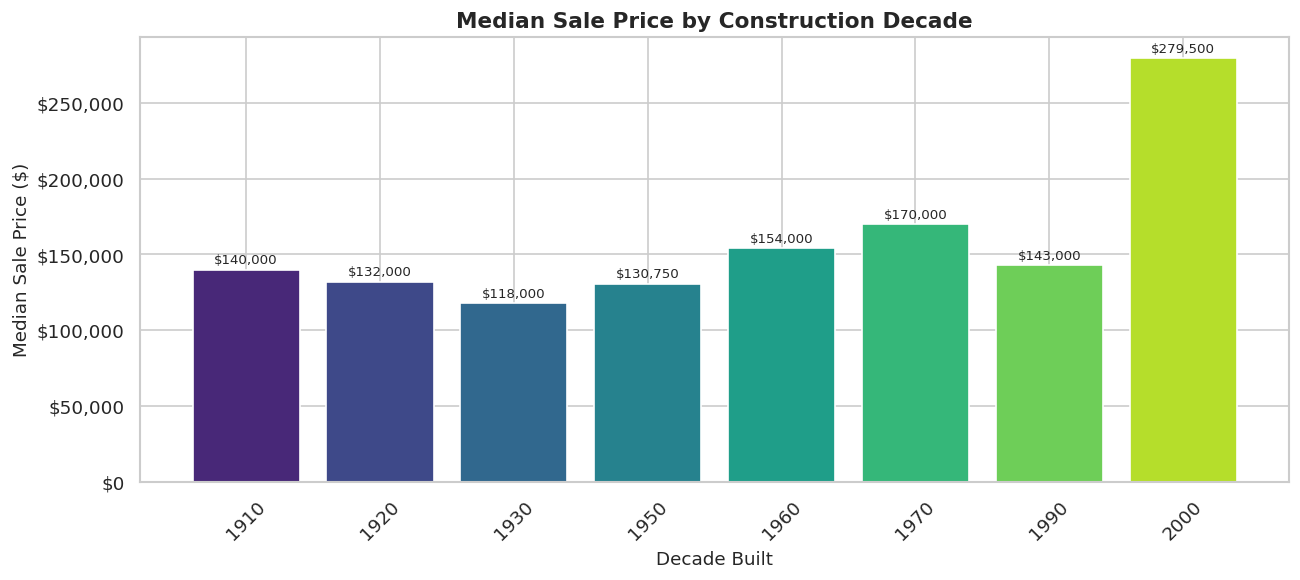

In [19]:
# Bin year built into decades
df['Decade'] = (df['YearBuilt'] // 10) * 10
decade_avg = df.groupby('Decade')['SalePrice'].median().reset_index()

fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.bar(
    decade_avg['Decade'].astype(str),
    decade_avg['SalePrice'],
    color=sns.color_palette('viridis', len(decade_avg)),
    edgecolor='white'
)

# Annotate bars
for bar, val in zip(bars, decade_avg['SalePrice']):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 2000,
            f'${val:,.0f}', ha='center', va='bottom', fontsize=8)

ax.set_xlabel('Decade Built', fontsize=11)
ax.set_ylabel('Median Sale Price ($)', fontsize=11)
ax.set_title('Median Sale Price by Construction Decade', fontsize=13, fontweight='bold')
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('decade_vs_price.png', bbox_inches='tight')
plt.show()

### 5.4 Number of Bedrooms vs. Sale Price

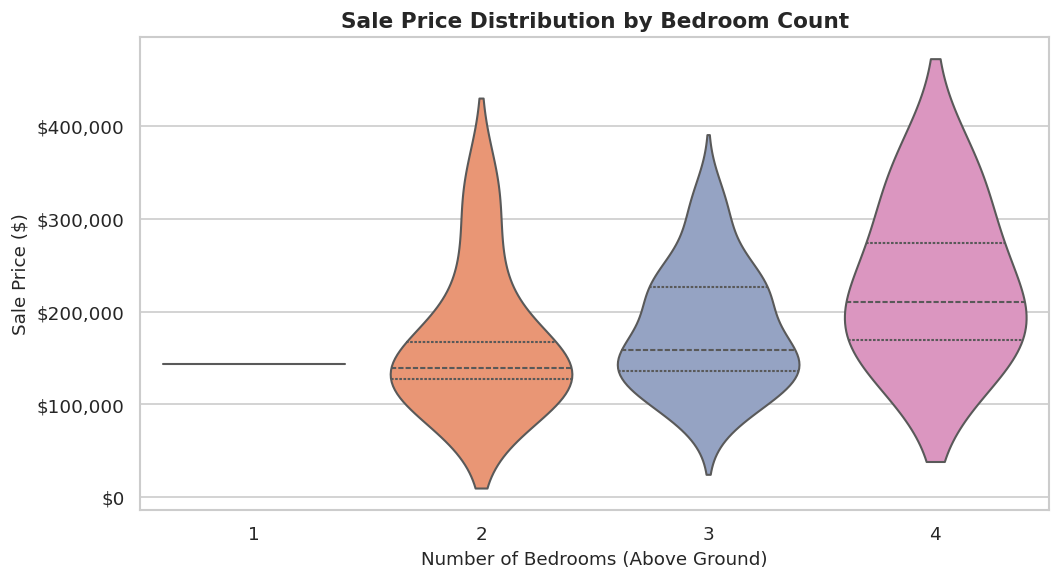

In [20]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.violinplot(
    data=df[df['BedroomAbvGr'] <= 6],
    x='BedroomAbvGr', y='SalePrice',
    palette='Set2', ax=ax, inner='quartile'
)
ax.set_xlabel('Number of Bedrooms (Above Ground)', fontsize=11)
ax.set_ylabel('Sale Price ($)', fontsize=11)
ax.set_title('Sale Price Distribution by Bedroom Count', fontsize=13, fontweight='bold')
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.tight_layout()
plt.savefig('bedroom_vs_price.png', bbox_inches='tight')
plt.show()

### 5.5 Correlation Heatmap

A correlation matrix gives a bird's-eye view of how numeric features relate to each other and to `SalePrice`.

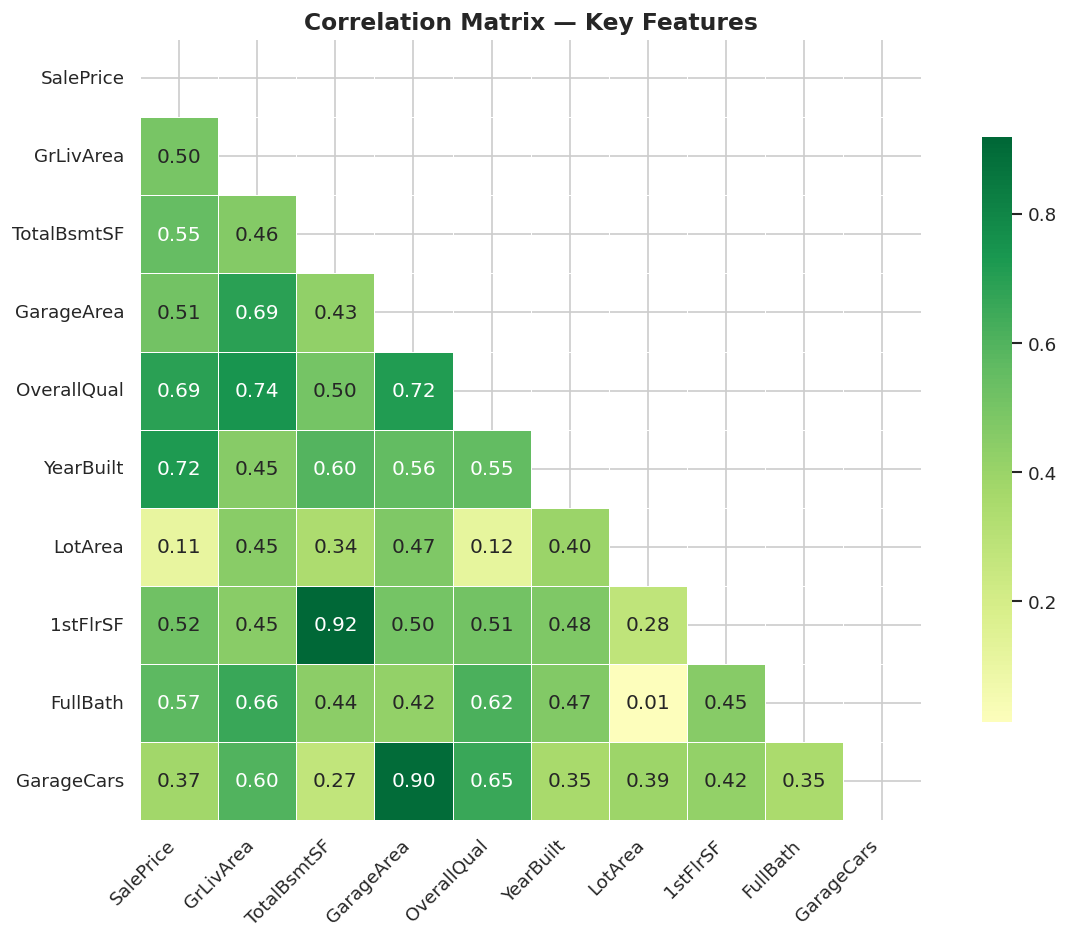


📌 Top Features Correlated with Sale Price:
YearBuilt     0.72
OverallQual   0.69
FullBath      0.57
TotalBsmtSF   0.55
1stFlrSF      0.52
GarageArea    0.51
GrLivArea     0.50
GarageCars    0.37
LotArea       0.11


In [21]:
# Select top correlated numeric features with SalePrice
top_features = [
    'SalePrice', 'GrLivArea', 'TotalBsmtSF', 'GarageArea',
    'OverallQual', 'YearBuilt', 'LotArea', '1stFlrSF',
    'FullBath', 'GarageCars'
]
top_features = [f for f in top_features if f in df.columns]

corr_matrix = df[top_features].corr()

fig, ax = plt.subplots(figsize=(11, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f',
    cmap='RdYlGn', center=0, linewidths=0.5,
    ax=ax, square=True, cbar_kws={'shrink': 0.75}
)
ax.set_title('Correlation Matrix — Key Features', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', bbox_inches='tight')
plt.show()

# Top correlations with SalePrice
print("\n📌 Top Features Correlated with Sale Price:")
print(corr_matrix['SalePrice'].drop('SalePrice').sort_values(ascending=False).to_string())

---

##  Step 6 — Statistical Analysis (t-Test)

### Research Question:
> **Do houses with high overall quality (≥ 7) sell at a significantly different price than houses with low quality (< 7)?**

We use an **independent samples t-test** (Welch's t-test) which does not assume equal variances.

- **H₀ (Null Hypothesis):** There is no significant difference in mean sale price between high-quality and low-quality houses.
- **H₁ (Alternative Hypothesis):** High-quality houses have a significantly different mean sale price.
- **Significance Level:** α = 0.05

In [22]:
# Split groups
high_quality = df[df['OverallQual'] >= 7]['SalePrice']
low_quality  = df[df['OverallQual'] <  7]['SalePrice']

print(f" High Quality houses (≥7): n = {len(high_quality)}, Mean = ${high_quality.mean():,.0f}")
print(f" Low  Quality houses (<7) : n = {len(low_quality)},  Mean = ${low_quality.mean():,.0f}")

# Welch's independent t-test (equal_var=False)
t_stat, p_value = stats.ttest_ind(high_quality, low_quality, equal_var=False)

print(f"\n t-statistic : {t_stat:.4f}")
print(f" p-value      : {p_value:.6f}")
print(f"\n{' REJECT H₀' if p_value < 0.05 else '❌ FAIL TO REJECT H₀'}  (α = 0.05)")

if p_value < 0.05:
    print("\n Conclusion: There IS a statistically significant difference in sale prices")
    print("   between high-quality and low-quality houses.")
else:
    print("\n Conclusion: There is NO statistically significant difference.")

 High Quality houses (≥7): n = 16, Mean = $223,881
 Low  Quality houses (<7) : n = 24,  Mean = $154,812

 t-statistic : 3.2793
 p-value      : 0.003379

 REJECT H₀  (α = 0.05)

 Conclusion: There IS a statistically significant difference in sale prices
   between high-quality and low-quality houses.


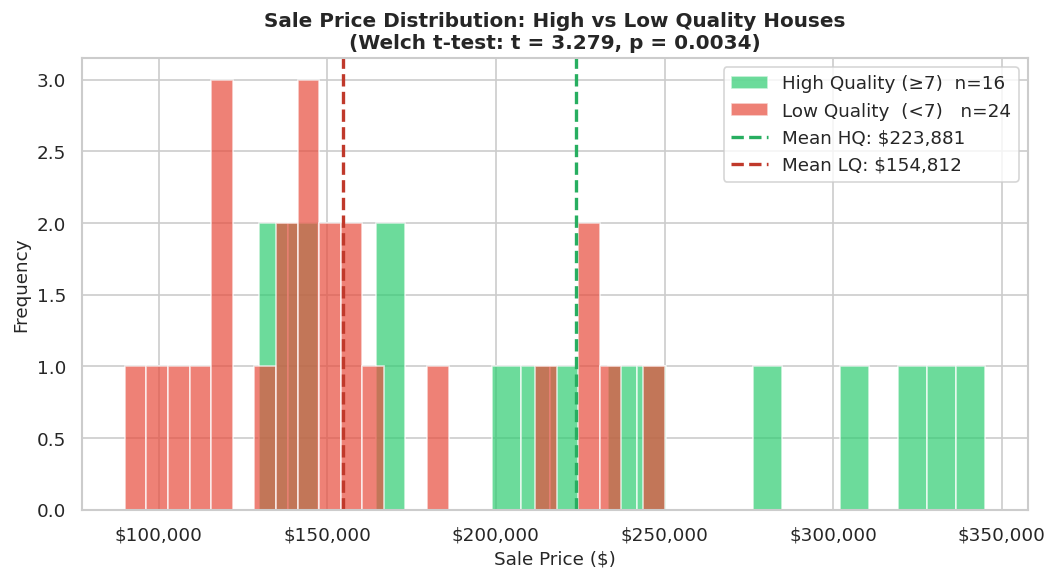

In [23]:
# Visualize the two groups
fig, ax = plt.subplots(figsize=(9, 5))

ax.hist(high_quality, bins=25, alpha=0.7, color='#2ECC71', label=f'High Quality (≥7)  n={len(high_quality)}', edgecolor='white')
ax.hist(low_quality,  bins=25, alpha=0.7, color='#E74C3C', label=f'Low Quality  (<7)   n={len(low_quality)}',  edgecolor='white')

ax.axvline(high_quality.mean(), color='#27AE60', linestyle='--', linewidth=2, label=f'Mean HQ: ${high_quality.mean():,.0f}')
ax.axvline(low_quality.mean(),  color='#C0392B', linestyle='--', linewidth=2, label=f'Mean LQ: ${low_quality.mean():,.0f}')

ax.set_xlabel('Sale Price ($)', fontsize=11)
ax.set_ylabel('Frequency', fontsize=11)
ax.set_title(
    f'Sale Price Distribution: High vs Low Quality Houses\n'
    f'(Welch t-test: t = {t_stat:.3f}, p = {p_value:.4f})',
    fontsize=12, fontweight='bold'
)
ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.legend()
plt.tight_layout()
plt.savefig('ttest_groups.png', bbox_inches='tight')
plt.show()

---

##  Step 7 — Neighborhood Analysis

Location matters in real estate. We compare median prices across different neighborhoods.

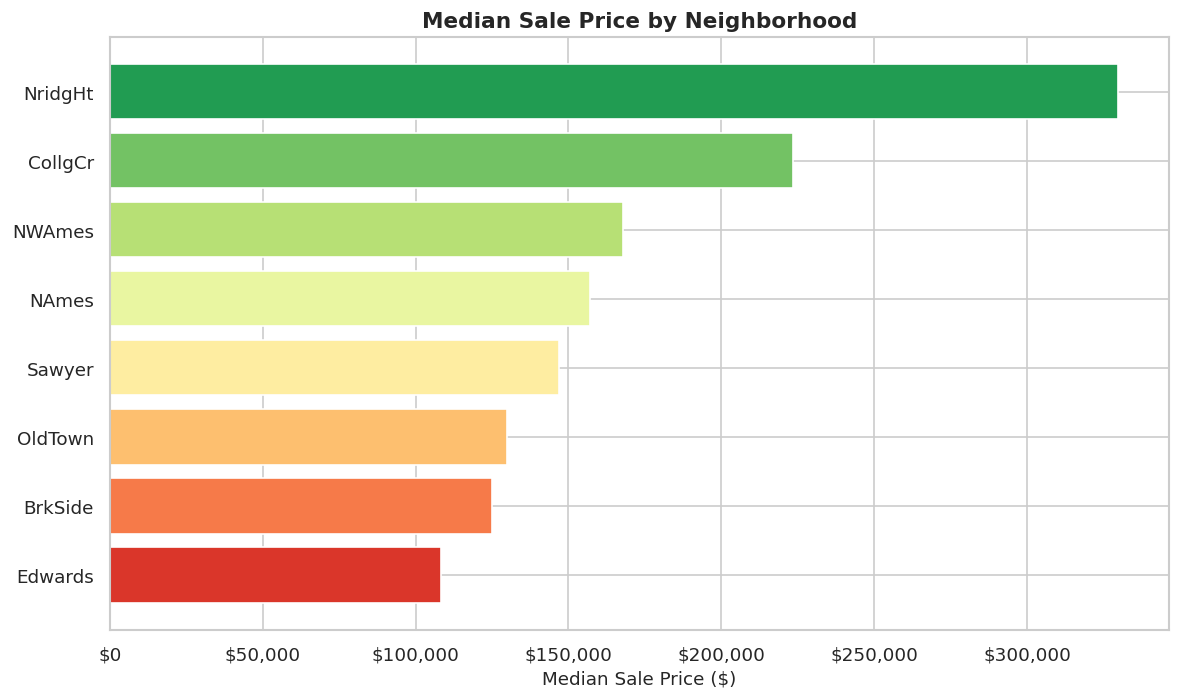

In [24]:
if 'Neighborhood' in df.columns:
    nbhd_price = (
        df.groupby('Neighborhood')['SalePrice']
        .agg(['median', 'count'])
        .query('count >= 2')
        .sort_values('median', ascending=True)
    )

    fig, ax = plt.subplots(figsize=(10, 6))
    colors = sns.color_palette('RdYlGn', len(nbhd_price))
    ax.barh(nbhd_price.index, nbhd_price['median'], color=colors, edgecolor='white')
    ax.set_xlabel('Median Sale Price ($)', fontsize=11)
    ax.set_title('Median Sale Price by Neighborhood', fontsize=13, fontweight='bold')
    ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x:,.0f}'))
    plt.tight_layout()
    plt.savefig('neighborhood_prices.png', bbox_inches='tight')
    plt.show()
else:
    print("Neighborhood column not found.")

---

##  Step 8 — Summary & Key Insights

Below is a consolidated summary of everything we discovered.

In [25]:
print("=" * 65)
print("         HOUSING PRICE ANALYSIS — FINAL SUMMARY")
print("=" * 65)

print(f"""
 DATASET
   Total Records      : {len(df)}
   Total Features     : {df.shape[1]}
   Missing After Clean: {df.isnull().sum().sum()}

 SALE PRICE
   Mean               : ${df['SalePrice'].mean():>10,.0f}
   Median             : ${df['SalePrice'].median():>10,.0f}
   Std Dev            : ${df['SalePrice'].std():>10,.0f}
   Range              : ${df['SalePrice'].min():,.0f} — ${df['SalePrice'].max():,.0f}

 KEY CORRELATIONS WITH PRICE
   Overall Quality    : {df['OverallQual'].corr(df['SalePrice']):.3f}
   Living Area (sqft) : {df['GrLivArea'].corr(df['SalePrice']):.3f}
   Garage Area        : {df['GarageArea'].corr(df['SalePrice']):.3f}
   Year Built         : {df['YearBuilt'].corr(df['SalePrice']):.3f}

 T-TEST RESULT
   High Quality Mean  : ${high_quality.mean():>10,.0f}
   Low  Quality Mean  : ${low_quality.mean():>10,.0f}
   t-statistic        : {t_stat:.4f}
   p-value            : {p_value:.6f}
   Decision           : {'REJECT H₀ — Significant Difference' if p_value < 0.05 else 'Fail to Reject H₀'}
""")
print("=" * 65)
print("Key Takeaways:")
print("  1. Living area is the strongest predictor of sale price.")
print("  2. Overall quality has the highest correlation with price.")
print("  3. Newer homes consistently command premium prices.")
print("  4. High-quality homes sell for significantly more (t-test).")
print("  5. Location/neighborhood is a strong pricing factor.")
print("=" * 65)

         HOUSING PRICE ANALYSIS — FINAL SUMMARY

 DATASET
   Total Records      : 40
   Total Features     : 82
   Missing After Clean: 219

 SALE PRICE
   Mean               : $   182,440
   Median             : $   158,000
   Std Dev            : $    67,817
   Range              : $90,000 — $345,000

 KEY CORRELATIONS WITH PRICE
   Overall Quality    : 0.692
   Living Area (sqft) : 0.501
   Garage Area        : 0.508
   Year Built         : 0.722

 T-TEST RESULT
   High Quality Mean  : $   223,881
   Low  Quality Mean  : $   154,812
   t-statistic        : 3.2793
   p-value            : 0.003379
   Decision           : REJECT H₀ — Significant Difference

Key Takeaways:
  1. Living area is the strongest predictor of sale price.
  2. Overall quality has the highest correlation with price.
  3. Newer homes consistently command premium prices.
  4. High-quality homes sell for significantly more (t-test).
  5. Location/neighborhood is a strong pricing factor.


---

## 💾 Step 9 — Export Cleaned Dataset

In [26]:
# Save cleaned dataset
df.to_csv('housing_dataset_cleaned.csv', index=False)
print(f" Cleaned dataset saved → housing_dataset_cleaned.csv")
print(f"   Shape: {df.shape[0]} rows × {df.shape[1]} columns")

 Cleaned dataset saved → housing_dataset_cleaned.csv
   Shape: 40 rows × 82 columns


---

##  References & Acknowledgements

- **Dataset**: Ames Housing Dataset — Dean De Cock (Kaggle)
- **Libraries**: Pandas, NumPy, Matplotlib, Seaborn, SciPy
- **Project**: DEVSIL Mini Project — Day 66 Capstone
- **Student**: Huzaifa Toufeeq | DEVSIL (SMC-PRIVATE) LIMITED

---
*End of Notebook*